In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

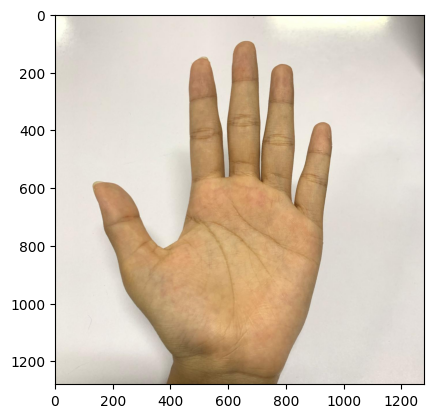

In [3]:
tangan = plt.imread('assets/telapaktangan.jpeg')
plt.imshow(tangan)
plt.show()

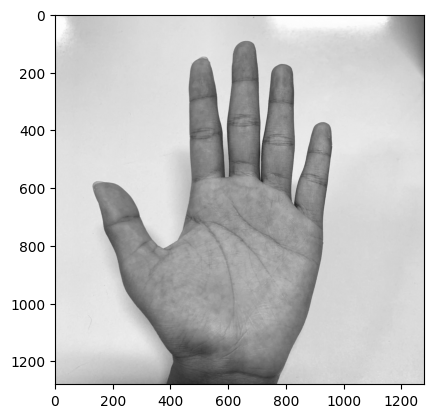

(1280, 1280)


In [7]:
tangan_gray = cv2.cvtColor(tangan, cv2.COLOR_RGB2GRAY)
plt.imshow(tangan_gray, cmap='gray')
plt.show()
print(tangan_gray.shape)

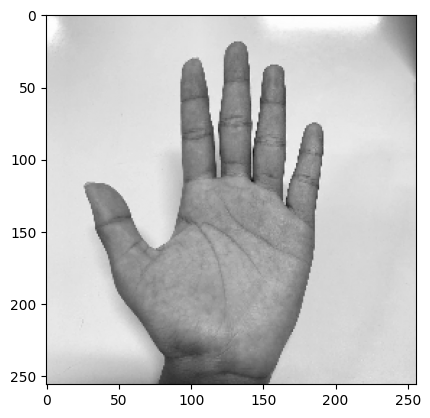

(256, 256)


In [6]:
def fungsi_dua(image, new_width, new_height): 
    old_height, old_width = image.shape[:2] 
    resized_image = np.zeros((new_height, new_width), 
dtype=np.uint8) 
    for i in range(new_height): 
        for j in range(new_width): 
            x = int(j * old_width / new_width) 
            y = int(i * old_height / new_height) 
            resized_image[i, j] = image[y, x] 
    return resized_image 

resize_tangan = fungsi_dua(tangan_gray, 256, 256)
plt.imshow(resize_tangan, cmap='gray')
plt.show()
print(resize_tangan.shape)


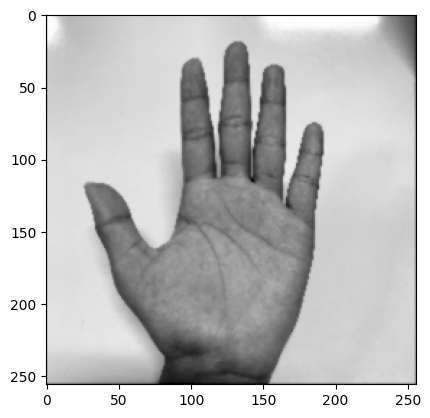

In [17]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
 ])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sharp_tangan = convolution (resize_tangan, kernelSharpening)
plt.imshow(sharp_tangan, cmap='gray')
plt.show()

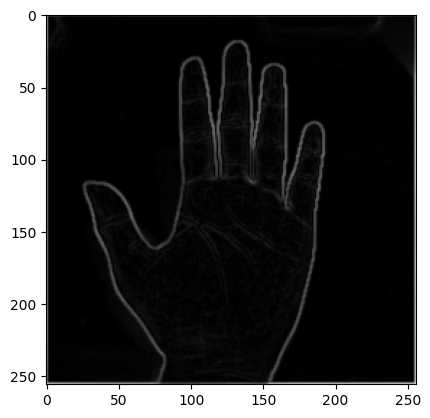

In [23]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)


robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)


robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

prewitt_tangan = edge(sharp_tangan, prewittX, prewittY)
plt.imshow(prewitt_tangan, cmap='gray')
plt.show()

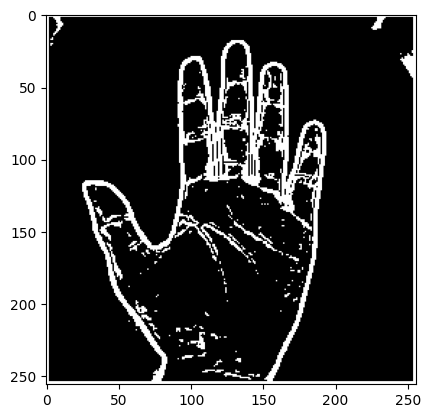

In [52]:
def fungsi_satu(img, batas): 
    baris, kolom = img.shape 
    canvas = np.zeros_like(img, dtype=np.uint8) 
    for i in range(baris): 
        for j in range(kolom): 
            if(img[i,j] > batas): 
                canvas[i,j] = 255 
            elif(img[i,j] <= batas): 
                canvas[i,j] = 0 
    return canvas 

thresholding_tangan = fungsi_satu(prewitt_tangan, 12)
plt.imshow(thresholding_tangan, cmap='gray')
plt.show()

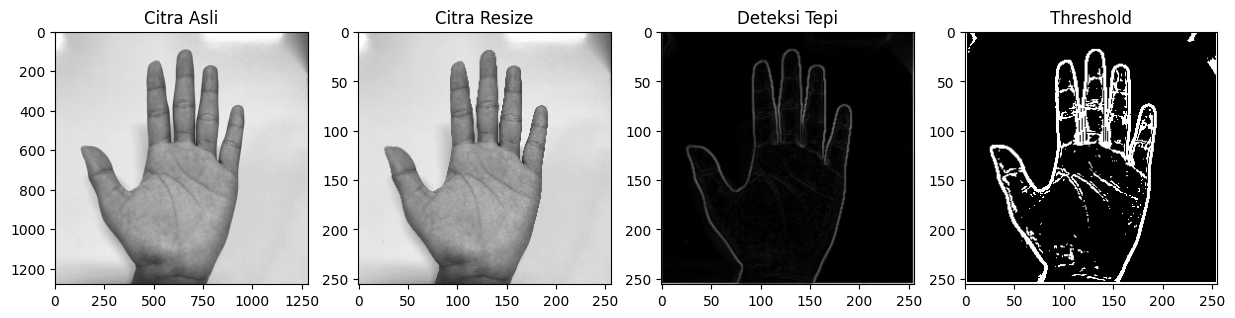

In [57]:
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.title("Citra Asli")
plt.imshow(tangan_gray, cmap='gray')

plt.subplot(1,4,2)
plt.title("Citra Resize")
plt.imshow(resize_tangan, cmap='gray')

plt.subplot(1,4,3)
plt.title("Deteksi Tepi")
plt.imshow(prewitt_tangan, cmap='gray')

plt.subplot(1,4,4)
plt.title("Threshold")
plt.imshow(thresholding_tangan, cmap='gray')

plt.show()

In [109]:
kernel_diamond = np.array([ 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1] 
]) 
 
kernel_cross = np.array([ 
    [1,1,1], 
    [1,1,1], 
    [1,1,1] 
]) 
 
kernel_x = np.array([ 
    [1,0,0,0,1], 
    [0,1,0,1,0], 
    [0,0,1,0,0], 
    [0,1,0,1,0], 
    [1,0,0,0,1] 
], dtype=np.uint8) 

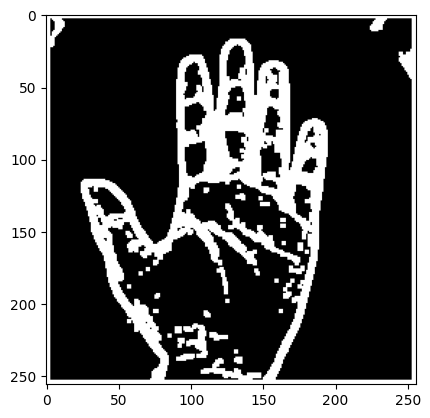

In [110]:
def metode_satu(image, kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height//2 
    hasil = np.zeros((height, width)) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil 

dilasi = metode_satu(thresholding_tangan, kernel_cross)
plt.imshow(dilasi, cmap='gray')
plt.show()

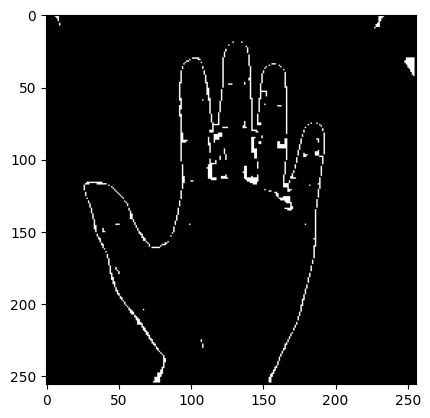

In [112]:
def metode_dua(image, kernel):
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros_like(image)
    for i in range(center, image.shape[0] - center):
        for j in range(center, image.shape[1] - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

erosi = metode_dua(thresholding_tangan, kernel_cross)
plt.imshow(erosi, cmap='gray')
plt.show()

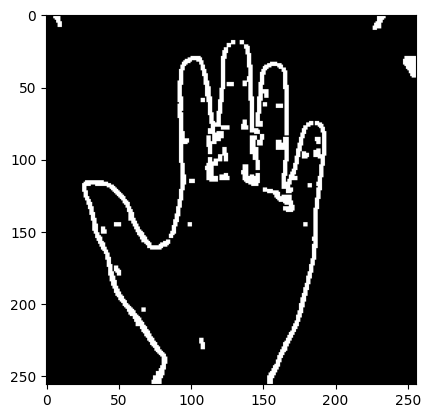

In [113]:
opening = metode_satu(erosi, kernel_cross)
plt.imshow(opening, cmap='gray')
plt.show()

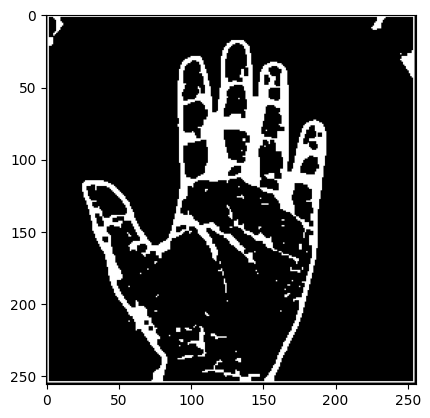

In [114]:
closing = metode_dua(dilasi, kernel_cross)
plt.imshow(closing, cmap='gray')
plt.show()

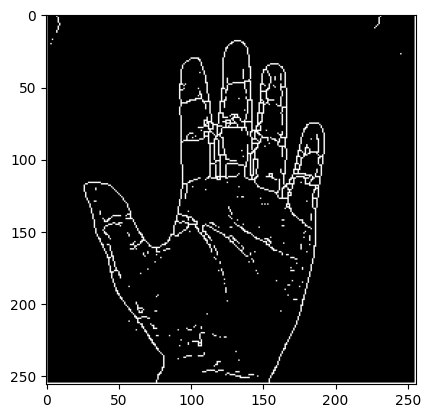

In [115]:
def Thinning(img): 
    binary = (img > 0).astype(np.uint8) 
    height, width = binary.shape 
    changed = True 
    while changed: 
        changed = False 
        hapus = [] 
        for i in range(1, height-1): 
            for j in range(1, width-1): 
                P1 = binary[i, j] 
                if P1 != 1: 
                    continue 
                P2 = binary[i-1, j] 
                P3 = binary[i-1, j+1] 
                P4 = binary[i, j+1] 
                P5 = binary[i+1, j+1] 
                P6 = binary[i+1, j] 
                P7 = binary[i+1, j-1] 
                P8 = binary[i, j-1] 
                P9 = binary[i-1, j-1] 
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9] 
                jumlah = np.sum(tetangga) 
                transisi = 0 
                urutan = tetangga + [P2] 
                for k in range(8): 
                    if urutan[k] == 0 and urutan[k+1] == 1: 
                        transisi += 1 
                if ( 
                    2 <= jumlah <= 6 and 
                    transisi == 1 and 
                    P2 * P4 * P6 == 0 and 
                    P4 * P6 * P8 == 0 
                ): 
                    hapus.append((i,j)) 
        if hapus: 
            changed = True 
            for i,j in hapus: 
                binary[i,j] = 0 
        hapus = [] 
        for i in range(1, height-1): 
            for j in range(1, width-1): 
 
                P1 = binary[i, j] 
                if P1 != 1: 
                    continue 
                P2 = binary[i-1, j] 
                P3 = binary[i-1, j+1] 
                P4 = binary[i, j+1] 
                P5 = binary[i+1, j+1] 
                P6 = binary[i+1, j] 
                P7 = binary[i+1, j-1] 
                P8 = binary[i, j-1] 
                P9 = binary[i-1, j-1] 
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9] 
                jumlah = np.sum(tetangga) 
                transisi = 0 
                urutan = tetangga + [P2] 
                for k in range(8): 
                    if urutan[k] == 0 and urutan[k+1] == 1: 
                        transisi += 1 
 
                if ( 
                    2 <= jumlah <= 6 and 
                    transisi == 1 and 
                    P2 * P4 * P8 == 0 and 
                    P2 * P6 * P8 == 0 
                ): 
                    hapus.append((i,j)) 
        if hapus: 
            changed = True 
            for i,j in hapus: 
                binary[i,j] = 0 
    return binary * 255 

thinning = Thinning (thresholding_tangan)
plt.imshow(thinning, cmap='gray')
plt.show()

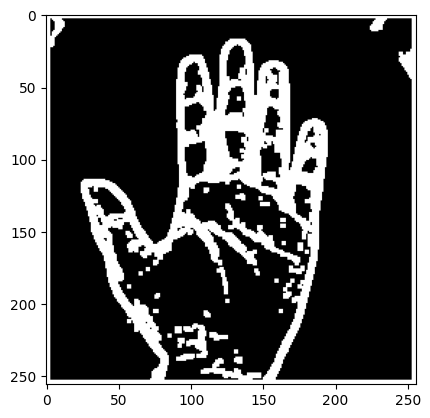

In [116]:
def Thickening(img, kernel, iterasi=1): 
    hasil = img.copy() 
    for _ in range(iterasi): 
        hasil = metode_satu(hasil, kernel) 
    return hasil 

thickening = Thickening (thresholding_tangan, kernel_cross, iterasi=1)
plt.imshow(thickening, cmap='gray')
plt.show()

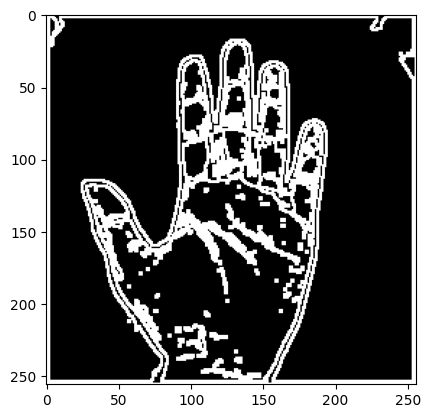

In [117]:
gradient_morph = dilasi- erosi
plt.imshow(gradient_morph, cmap='gray')
plt.show()

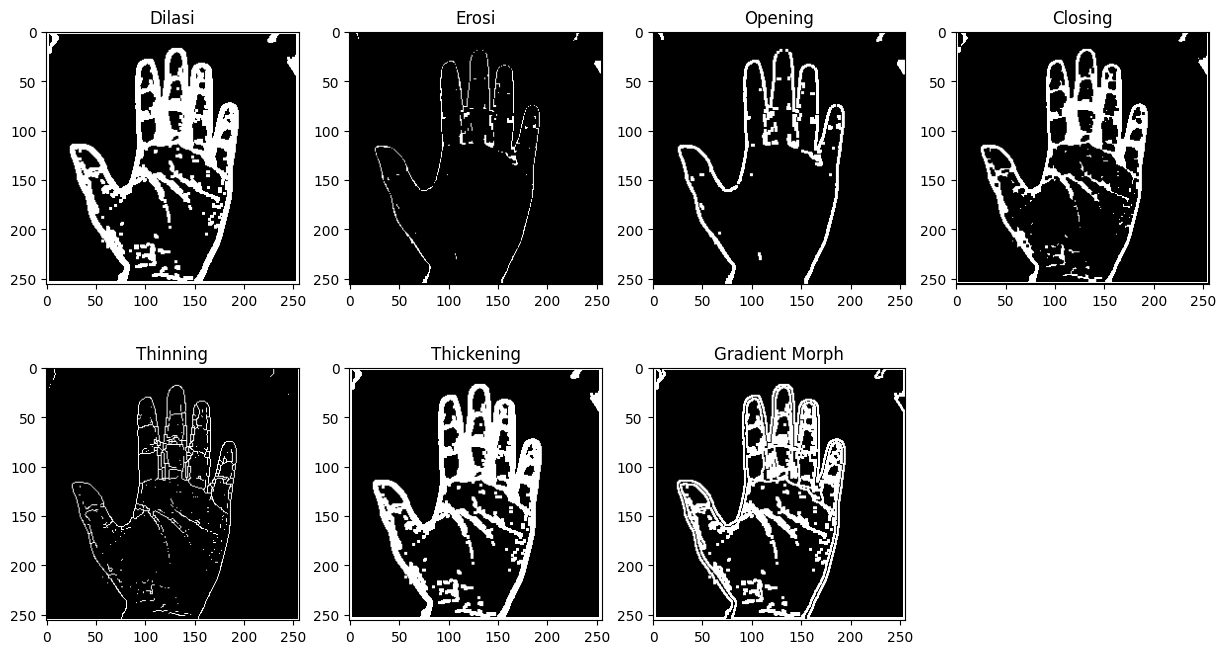

In [118]:
plt.figure(figsize=(15,8))

plt.subplot(2,4,1)
plt.title("Dilasi")
plt.imshow(dilasi, cmap='gray')

plt.subplot(2,4,2)
plt.title("Erosi")
plt.imshow(erosi, cmap='gray')

plt.subplot(2,4,3)
plt.title("Opening")
plt.imshow(opening, cmap='gray')

plt.subplot(2,4,4)
plt.title("Closing")
plt.imshow(closing, cmap='gray')

plt.subplot(2,4,5)
plt.title("Thinning")
plt.imshow(thinning, cmap='gray')

plt.subplot(2,4,6)
plt.title("Thickening")
plt.imshow(thickening, cmap='gray')

plt.subplot(2,4,7)
plt.title("Gradient Morph")
plt.imshow(gradient_morph, cmap='gray')

plt.show()

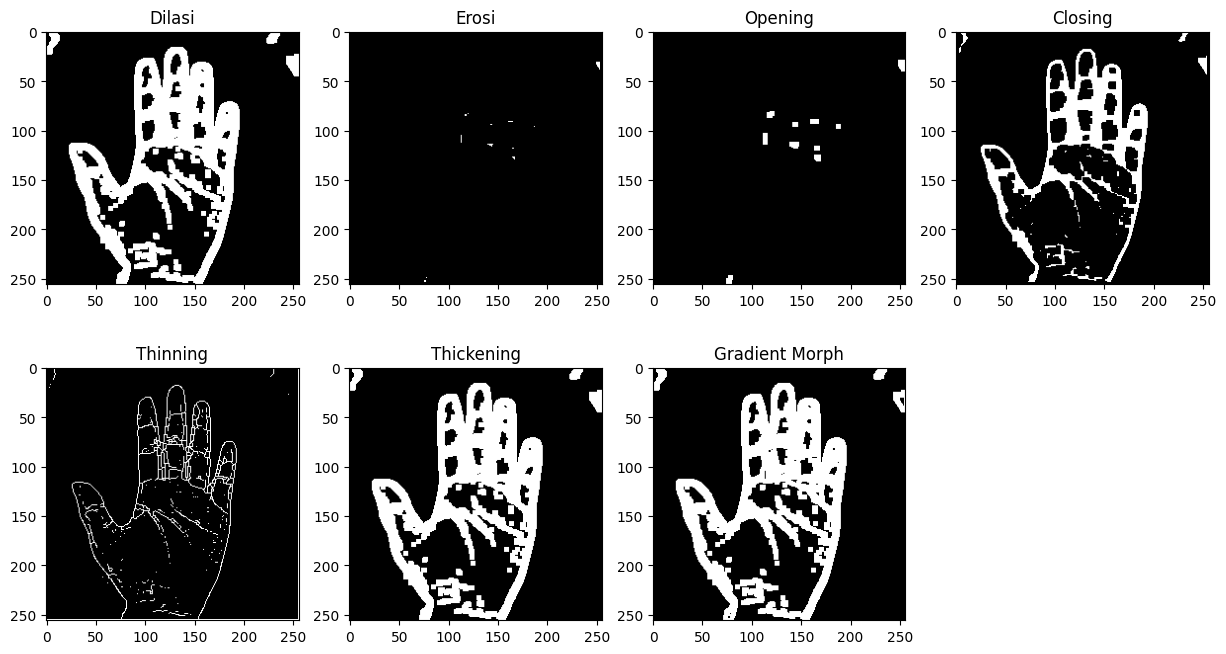

In [122]:
dilasi2 = metode_satu(thresholding_tangan, kernel_diamond)
erosi2 = metode_dua(thresholding_tangan, kernel_diamond)
opening2 = metode_satu(erosi2, kernel_diamond)
closing2 = metode_dua(dilasi2, kernel_diamond)
thickening2 = Thickening (thresholding_tangan, kernel_diamond, iterasi=1)
gradient_morph2 = dilasi2- erosi2

plt.figure(figsize=(15,8))

plt.subplot(2,4,1)
plt.title("Dilasi")
plt.imshow(dilasi2, cmap='gray')

plt.subplot(2,4,2)
plt.title("Erosi")
plt.imshow(erosi2, cmap='gray')

plt.subplot(2,4,3)
plt.title("Opening")
plt.imshow(opening2, cmap='gray')

plt.subplot(2,4,4)
plt.title("Closing")
plt.imshow(closing2, cmap='gray')

plt.subplot(2,4,5)
plt.title("Thinning")
plt.imshow(thinning2, cmap='gray')

plt.subplot(2,4,6)
plt.title("Thickening")
plt.imshow(thickening2, cmap='gray')

plt.subplot(2,4,7)
plt.title("Gradient Morph")
plt.imshow(gradient_morph2, cmap='gray')

plt.show()